# Instrument-free AltAz sky-brightness map

This example computes a rectangular map of the night-sky photon radiance in local
altitude and azimuth. It deliberately stops **before** an instrument model:
there are no camera pixels, effective aperture, or telescope throughput.

We will:

1. define a regular grid over the visible sky,
2. select a wavelength interval with a unit-transmission bandpass,
3. evaluate direct airglow and Moon-scattered light with nsb2's explicit solvers,
4. add the radiance components and plot them directly in AltAz coordinates.

The result has units of photons per second, square metre, and steradian. A
telescope model would turn that surface brightness into per-pixel count rates,
but that projection is intentionally outside this notebook.

In [1]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import AltAz, EarthLocation, SkyCoord, SkyOffsetFrame
from astropy.time import Time
from matplotlib.colors import LogNorm

from nsb2.atmosphere import SingleScatteringAtmosphere
from nsb2.core.solver import ExplicitDirectSolver, ExplicitScatteredSolver
from nsb2.core.spectral import Bandpass
from nsb2.emitter import airglow, moon

## 1. Observation geometry and sky grid

The example uses the CTAO-North site on La Palma at a fixed UTC time. nsb2
source queries expect an observation frame with an origin, so we use a
SkyOffsetFrame centred on the zenith only as a carrier for the time and
location. It is **not** a telescope pointing.

The actual evaluation positions are the sky_coords below: a regular grid in
the underlying local AltAz frame. We stop at 5 degrees altitude because
simple plane-parallel atmosphere models become unreliable at the geometric
horizon.

In [2]:
location = EarthLocation.from_geodetic(
    lon=-17.892005 * u.deg,
    lat=28.761847 * u.deg,
    height=2200 * u.m,
)
obstime = Time("2027-01-16T22:00:00", scale="utc")
horizon = AltAz(obstime=obstime, location=location)

zenith = SkyCoord(az=0 * u.deg, alt=90 * u.deg, frame=horizon)
observation = SkyOffsetFrame(origin=zenith)

azimuth = np.linspace(0, 360, 145)
altitude = np.linspace(5, 90, 35)
az_grid, alt_grid = np.meshgrid(azimuth, altitude)
sky_coords = SkyCoord(
    az=az_grid * u.deg,
    alt=alt_grid * u.deg,
    frame=horizon,
)

print(
    f"Evaluation grid: {sky_coords.shape[0]} altitudes x {sky_coords.shape[1]} azimuths"
)

Evaluation grid: 35 altitudes x 145 azimuths


## 2. Wavelength interval and atmosphere

A spectral interval is still needed because nsb2's emitters are
wavelength-resolved. The Bandpass below is a simple unit-transmission window
from 350 to 650 nm. It selects wavelengths but does not represent a telescope.

The atmosphere uses the same single-scattering ingredients as the telescope
tutorials: Kasten-Young airmass, wavelength-dependent Rayleigh and aerosol
optical depths, and a Henyey-Greenstein aerosol asymmetry parameter.

In [3]:
bandpass = Bandpass(
    np.linspace(350, 650, 31) * u.nm,
    np.ones(31),
)


def airmass(zenith_angle):
    zenith_deg = np.rad2deg(zenith_angle)
    return 1 / (np.cos(zenith_angle) + 0.50572 * (96.07995 - zenith_deg) ** (-1.6364))


atmosphere = SingleScatteringAtmosphere(
    airmass_func=airmass,
    tau_rayleigh=lambda wavelength: (
        0.00879 * wavelength.to_value(u.micron) ** -4.09 * np.exp(-8.0 / 8.0)
    ),
    tau_mie=lambda wavelength: (
        0.5 * (wavelength.to_value(u.nm) / 380) ** -1.0 * np.exp(-1.8 / 1.54)
    ),
    tau_absorption=lambda wavelength: np.zeros(wavelength.shape),
    g=0.8,
)

## 3. Direct diffuse airglow

airglow.from_eso_skycalc returns a diffuse LonLatSource. Calling query_direct
at our grid positions creates a SourceField; the returned pixel references
are ignored because there is no instrument.

ExplicitDirectSolver applies atmospheric extinction and integrates the
spectrum through the wavelength window. The source has one spectral component,
so the last axis has length one.

In [4]:
radiance_unit = 1 / u.s / u.m**2 / u.sr
flat_coords = sky_coords.reshape(-1)

glow = airglow.from_eso_skycalc(height=87 * u.km, sfu=100)
airglow_field, _ = glow.query_direct(
    observation,
    flat_coords,
    np.zeros(flat_coords.shape),
)

direct_solver = ExplicitDirectSolver()
airglow_radiance = (
    direct_solver.compute_rates(glow, airglow_field, atmosphere, bandpass)[:, 0]
    .reshape(sky_coords.shape)
    .to(radiance_unit, equivalencies=u.dimensionless_angles())
)

print(f"Airglow range: {airglow_radiance.min():.3g} to {airglow_radiance.max():.3g}")

Airglow range: 1.22e+12 1 / (s sr m2) to 2.56e+12 1 / (s sr m2)


## 4. Moonlight scattered across the sky

The direct lunar disk is a point source, so it is not meaningful on a smooth
surface-brightness grid. Instead, we query the Moon as the illuminator of the
atmosphere and use ExplicitScatteredSolver to evaluate scattered moonlight at
every AltAz position.

The solver returns one axis for illuminating sources and three ROLO lunar
brightness variants. We sum over sources and select the median variant.

In [5]:
lunar_source = moon.from_noll2013()
lunar_field = lunar_source.query_scattered(observation)

scattered_solver = ExplicitScatteredSolver()
moon_components = scattered_solver.compute_rates(
    lunar_source,
    lunar_field,
    atmosphere,
    bandpass,
    sky_coords,
)
moon_radiance = moon_components.sum(axis=-2)[..., 1].to(
    radiance_unit, equivalencies=u.dimensionless_angles()
)

moon_coord = lunar_field.coords[0]
print(
    f"Moon position: az={moon_coord.az.deg:.1f} deg, alt={moon_coord.alt.deg:.1f} deg"
)
print(
    f"Scattered moonlight range: {moon_radiance.min():.3g} to {moon_radiance.max():.3g}"
)

Moon position: az=260.2 deg, alt=58.5 deg
Scattered moonlight range: 2.74e+12 1 / (s sr m2) to 1.72e+14 1 / (s sr m2)


## 5. Add the components

Both solver outputs are radiances in the same wavelength interval, so they can
be added directly. This example contains direct airglow and scattered
moonlight. Zodiacal light or a diffuse stellar map can be evaluated on the
same grid and added in exactly the same way.

In [6]:
total_radiance = airglow_radiance + moon_radiance

for name, values in {
    "airglow": airglow_radiance,
    "scattered Moon": moon_radiance,
    "total": total_radiance,
}.items():
    print(f"{name:15s}: median={np.median(values):.3g}, max={values.max():.3g}")

airglow        : median=1.54e+12 1 / (s sr m2), max=2.56e+12 1 / (s sr m2)
scattered Moon : median=7.43e+12 1 / (s sr m2), max=1.72e+14 1 / (s sr m2)
total          : median=9.19e+12 1 / (s sr m2), max=1.73e+14 1 / (s sr m2)


## 6. Plot the rectangular AltAz map

This is a direct longitude/latitude-style view: azimuth is horizontal,
altitude is vertical, and no camera or telescope projection is applied.
Azimuth increases from north through east.

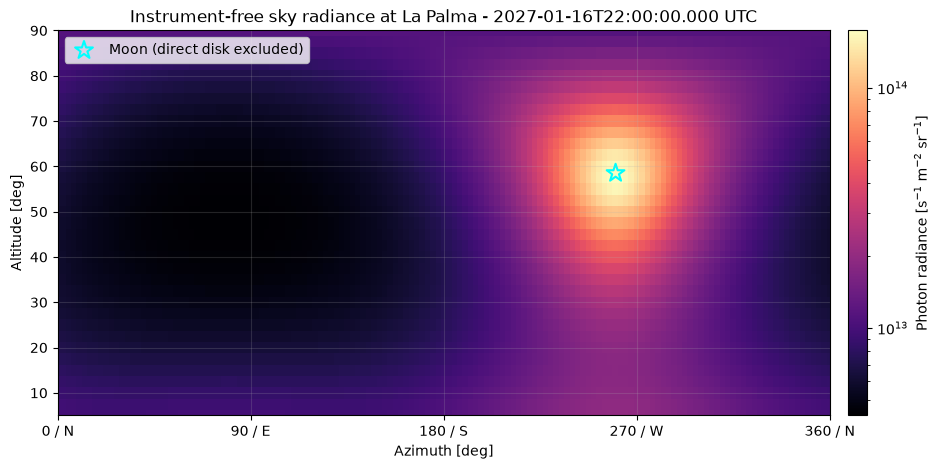

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

mesh = ax.pcolormesh(
    az_grid,
    alt_grid,
    total_radiance.value,
    shading="auto",
    cmap="magma",
    norm=LogNorm(),
)
ax.scatter(
    moon_coord.az.deg,
    moon_coord.alt.deg,
    marker="*",
    s=180,
    facecolor="none",
    edgecolor="cyan",
    linewidth=1.5,
    label="Moon (direct disk excluded)",
)

ax.set(
    xlim=(0, 360),
    ylim=(5, 90),
    xlabel="Azimuth [deg]",
    ylabel="Altitude [deg]",
    title=f"Instrument-free sky radiance at La Palma - {obstime.isot} UTC",
)
ax.set_xticks(
    [0, 90, 180, 270, 360],
    ["0 / N", "90 / E", "180 / S", "270 / W", "360 / N"],
)
ax.grid(alpha=0.2)
ax.legend(loc="upper left")

colorbar = fig.colorbar(mesh, ax=ax, pad=0.02)
colorbar.set_label(r"Photon radiance [s$^{-1}$ m$^{-2}$ sr$^{-1}$]")
plt.show()

## Interpreting and extending the result

The map is a band-integrated **sky radiance**, not a detector rate. To predict
camera counts, a later step would multiply or integrate this field with an
instrument's collecting area, angular acceptance, and wavelength-dependent
throughput. That is the projection intentionally omitted here.

Useful extensions are:

- change the bandpass to another wavelength interval or a measured filter curve,
- add zodiacal light with zodiacal.from_leinert1998(),
- add a diffuse stellar map and evaluate it through the direct solver,
- change the observation time to animate the lunar contribution across a night,
- increase the AltAz grid density for a smoother map.